
<img align="right" width="125" src="https://www.ou.nl/documents/40554/3255217/Logo_OU.jpg"/>

<br>


<center> <font size ="6" color='red'> AI for Prescriptive Analysis </font></center>
<br> 
<center> <font size ="5" color='red'> Discrete Event Simulation in Python</font></center>
<br> 


--------------------------


In [ ]:
from controller import *
mycontroller = Controller()
mytab = mycontroller.GetDashBoard(); tab_set = widgets.Tab([mytab]); tab_set.set_title(0,'Production Planning'); tab_set

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

exec_df = pd.read_csv(os.path.join("..", "data", "simulation", "EventExecutionData.csv"))

diagnose = True

print("Item batches: "+str(len(exec_df["Items"].unique())))

for batch in exec_df["Items"].unique():
    if pd.isnull(batch):
        continue
    sub_df = exec_df[exec_df["Items"] == batch]
    sub_df = sub_df.sort_values(['SimTime'])
    start = sub_df.iloc[0, sub_df.columns.get_loc('Location')]
    end = sub_df.iloc[len(sub_df)-1, sub_df.columns.get_loc('Location')]

    if batch =="1~17":
        display(sub_df)
    
        print("______________________________")
    

op1_df = exec_df[exec_df["Resource"] == "Operator 1"]


display(op1_df.head(20))

op2_df = exec_df[exec_df["Resource"] == "Operator 2"]


display(op2_df.head(20))

Item batches: 0


,ID,Product,Product/ID,Quantity To Produce,Deadline,Reference,Work Orders/Work Center,Work Orders/Work Center/ID,Processing Machine,Work Orders/Operation,...,Lateness (days),EventName,EventID,ProgressSteps,Items,Resource,Equipment,Location,SimTime,Date


,ID,Product,Product/ID,Quantity To Produce,Deadline,Reference,Work Orders/Work Center,Work Orders/Work Center/ID,Processing Machine,Work Orders/Operation,...,Lateness (days),EventName,EventID,ProgressSteps,Items,Resource,Equipment,Location,SimTime,Date


Item batches: 0
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~


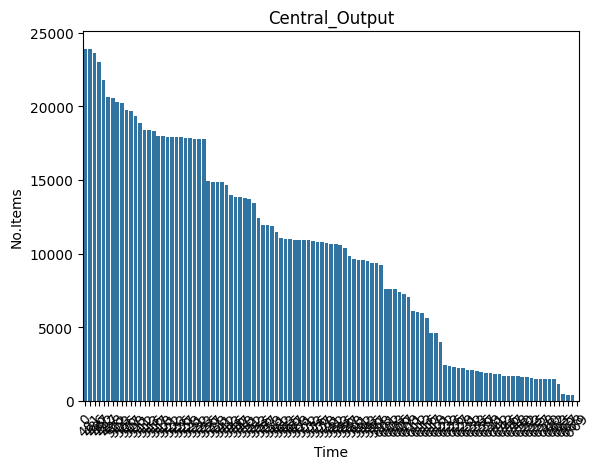

,BufferName,Time,No.Items
0,Central_Output,0,23888
1,Central_Output,481,23871
2,Central_Output,486,23629
3,Central_Output,487,23013
4,Central_Output,492,21759
...,...,...,...
95,Central_Output,648,1668
96,Central_Output,650,1638
97,Central_Output,652,1626
98,Central_Output,653,1554


______________________________


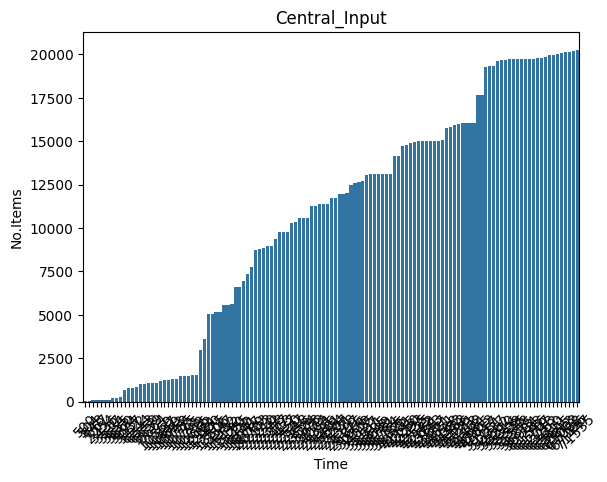

,BufferName,Time,No.Items
0,Central_Input,500,24
1,Central_Input,504,44
2,Central_Input,648,71
3,Central_Input,667,82
4,Central_Input,2254,99
...,...,...,...
95,Central_Input,45318,16027
96,Central_Input,45462,16037
97,Central_Input,46681,16047
98,Central_Input,46965,16057


______________________________


In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

exec_df = pd.read_csv(os.path.join("..", "data", "simulation", "EventExecutionData.csv"))

diagnose = True

print("Item batches: "+str(len(exec_df["Items"].unique())))

for batch in exec_df["Items"].unique():
    if pd.isnull(batch):
        continue
    sub_df = exec_df[exec_df["Items"] == batch]
    sub_df = sub_df.sort_values(['SimTime'])
    start = sub_df.iloc[0, sub_df.columns.get_loc('Location')]
    end = sub_df.iloc[len(sub_df)-1, sub_df.columns.get_loc('Location')]

    if batch !="1~17":
        display(sub_df)
    
        print("______________________________")
    

#process_df = exec_df[exec_df["EventName"] == "Machine Processing"]

for myloc in exec_df["Location"].unique():
    print("+++++++++++++++++++++++++++++++++++++++++++++++++++++++++")
    print("Location: ",myloc)
    sub_df = exec_df[exec_df["Location"] == myloc]
    sub_df  = sub_df[(sub_df["EventName"] == "Machine Setup") | (sub_df["EventName"] =="Machine Loading") | (sub_df["EventName"] == "Machine Processing") | (sub_df["EventName"] == "Machine Unloading")]
    if diagnose and len(sub_df)  > 0:
        for i,r in sub_df.iterrows():
            print(r["EventName"],r["EventID"],r["Location"],r["SimTime"])
        
        #display(sub_df)

    


print("~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~")
exec_df = pd.read_csv(os.path.join("..", "data", "simulation", "BufferData.csv"))

for buff in exec_df["BufferName"].unique():
    sub_df = exec_df[exec_df["BufferName"] == buff]
    agg_df = sub_df.groupby(['BufferName','Time'])['No.Items'].max().reset_index()
    agg_df = agg_df.rename(columns={agg_df.columns[-1]: "No.Items"})

    if buff in ["Central_Output","Central_Input"]:
        sns.barplot(agg_df, x="Time", y="No.Items", legend=False).set_title(buff)
        plt.xticks(rotation=45)
        plt.show()
        
        display(agg_df.head(100))
        print("______________________________")    

In [4]:
import pandas as pd

location_df = pd.read_csv(os.path.join("..", "data", "simulation", "LocationData.csv"))

for entity in location_df["EntityID"].unique():
    sub_df = location_df[location_df["EntityID"] == entity]
    display(sub_df)
    print("______________________________")
    

,EntityName,EntityID,Time,LocationName,LocationID
0,Operator 1,4,481,CentralBuffer_Location,0
4,Operator 1,4,482,CentralBuffer_Location,0
8,Operator 1,4,483,BW_(BKW_01)_Location,13
12,Operator 1,4,485,BW_(BKW_01)_Location,13
19,Operator 1,4,486,CentralBuffer_Location,0
...,...,...,...,...,...
4115,Operator 1,4,71441,OUT - Outsourced activity_(OUT - Outsourced)_L...,15
4117,Operator 1,4,71442,PACK_(VERP_P)_Location,14
4119,Operator 1,4,71445,PACK_(VERP_P)_Location,14
4122,Operator 1,4,71447,PACK_(VERP_P)_Location,14


______________________________


,EntityName,EntityID,Time,LocationName,LocationID
1,Operator 2,5,481,CentralBuffer_Location,0
5,Operator 2,5,482,CentralBuffer_Location,0
9,Operator 2,5,483,OUT - Outsourced activity_(OUT - Outsourced)_L...,15
13,Operator 2,5,485,OUT - Outsourced activity_(OUT - Outsourced)_L...,15
16,Operator 2,5,486,BW_(BKW_01)_Location,13
...,...,...,...,...,...
4116,Operator 2,5,71442,CentralBuffer_Location,0
4118,Operator 2,5,71443,PACK_(VERP_P)_Location,14
4120,Operator 2,5,71445,PACK_(VERP_P)_Location,14
4121,Operator 2,5,71446,PACK_(VERP_P)_Location,14


______________________________


,EntityName,EntityID,Time,LocationName,LocationID
2,Manual worker 1,7,481,CentralBuffer_Location,0
6,Manual worker 1,7,482,CentralBuffer_Location,0
10,Manual worker 1,7,483,BW_(BKW_01)_Location,13
14,Manual worker 1,7,485,BW_(BKW_01)_Location,13
17,Manual worker 1,7,486,OUT - Outsourced activity_(OUT - Outsourced)_L...,15
...,...,...,...,...,...
4076,Manual worker 1,7,67165,OUT - Outsourced activity_(OUT - Outsourced)_L...,15
4077,Manual worker 1,7,67166,OUT - Outsourced activity_(OUT - Outsourced)_L...,15
4078,Manual worker 1,7,67168,OUT - Outsourced activity_(OUT - Outsourced)_L...,15
4079,Manual worker 1,7,67170,OUT - Outsourced activity_(OUT - Outsourced)_L...,15


______________________________


,EntityName,EntityID,Time,LocationName,LocationID
3,Manual worker 2,8,481,CentralBuffer_Location,0
7,Manual worker 2,8,482,CentralBuffer_Location,0
11,Manual worker 2,8,483,OUT - Outsourced activity_(OUT - Outsourced)_L...,15
15,Manual worker 2,8,485,OUT - Outsourced activity_(OUT - Outsourced)_L...,15
18,Manual worker 2,8,486,BW_(BKW_01)_Location,13
...,...,...,...,...,...
3621,Manual worker 2,8,54129,M3-01_(FR3_01)_Location,1
3624,Manual worker 2,8,54174,M3-01_(FR3_01)_Location,1
3633,Manual worker 2,8,54240,CentralBuffer_Location,0
3639,Manual worker 2,8,55201,CentralBuffer_Location,0


______________________________


,EntityName,EntityID,Time,LocationName,LocationID
693,Operator 3,6,961,CentralBuffer_Location,0
694,Operator 3,6,962,MP1 - Material preparation - automatic sawing ...,16
695,Operator 3,6,964,MP1 - Material preparation - automatic sawing ...,16
696,Operator 3,6,994,VF2SS_(M3-03)_Location,5
697,Operator 3,6,996,VF2SS_(M3-03)_Location,5
...,...,...,...,...,...
4129,Operator 3,6,71533,PACK_(VERP_P)_Location,14
4130,Operator 3,6,71534,PACK_(VERP_P)_Location,14
4131,Operator 3,6,71535,CentralBuffer_Location,0
4132,Operator 3,6,71780,CentralBuffer_Location,0


______________________________


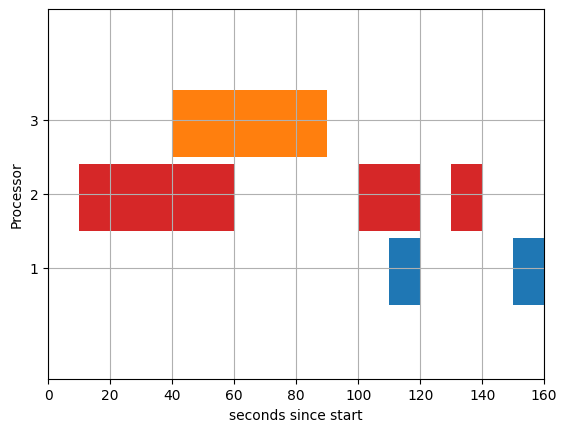

In [5]:
# Importing the matplotlib.pyplot
import matplotlib.pyplot as plt

# Declaring a figure "gnt"
fig, gnt = plt.subplots()

# Setting Y-axis limits
gnt.set_ylim(0, 50)

# Setting X-axis limits
gnt.set_xlim(0, 160)

# Setting labels for x-axis and y-axis
gnt.set_xlabel('seconds since start')
gnt.set_ylabel('Processor')

# Setting ticks on y-axis
gnt.set_yticks([15, 25, 35])
# Labelling tickes of y-axis
gnt.set_yticklabels(['1', '2', '3'])

# Setting graph attribute
gnt.grid(True)

# Declaring a bar in schedule
gnt.broken_barh([(40, 50)], (30, 9), facecolors =('tab:orange'))

# Declaring multiple bars in at same level and same width
gnt.broken_barh([(110, 10), (150, 10)], (10, 9),
                         facecolors ='tab:blue')

gnt.broken_barh([(10, 50), (100, 20), (130, 10)], (20, 9),
                                  facecolors =('tab:red'))


In [6]:
import pandas as pd

exec_df = pd.read_csv(os.path.join("..", "data", "simulation", "EventExecutionData.csv"))

demands_df = exec_df.groupby(['Items','ID','Product','Work Orders/Operation','EventName','EventID','Resource','Date'])['SimTime'].agg(lambda x:list(x)).reset_index()

for demand in demands_df['ID'].unique():
    demand_df = demands_df[demands_df["ID"] == demand]
    demand_df['Date']  = pd.to_datetime(demand_df['Date'], format="%Y-%m-%d %H:%M:%S")
    display(demand_df)


In [7]:
import pandas as pd 

milp_schedule_df = pd.read_csv(os.path.join("..", "data", "schedules", "TBRM_Plan_2026-08-19_R10_2026-09-01.csv"))

sim_schedule_df = pd.read_csv(os.path.join("..", "data", "simulation", "EventExecutionData.csv"))

sim_schedule_df = sim_schedule_df[["ID","Product","Product/ID","Quantity To Produce","Deadline","Reference","Work Orders/Work Center","Work Orders/Work Center/ID","Work Orders/Operation","Operation Order","Work Orders/Expected Duration","Work Orders/Start(SIM)","Work Orders/End(SIM)","Work Orders/Status(SIM)","Tardy(SIM)","Lateness (days)(SIM)"]]

schedule_df = pd.merge(milp_schedule_df, sim_schedule_df,  how="left", on=["ID","Product","Product/ID","Quantity To Produce","Deadline","Reference","Work Orders/Work Center","Work Orders/Work Center/ID","Work Orders/Operation","Operation Order","Work Orders/Expected Duration"])

schedule_df.to_csv(os.path.join("..", "data", "schedules", "Combined_Schedule.csv"),index = False)

FileNotFoundError: [Errno 2] No such file or directory: '..\\data\\schedules\\TBRM_Plan_2026-08-19_R10_2026-09-01.csv'

In [ ]:
import pandas as pd

events_df = pd.read_csv(os.path.join("Production_EventTypes.csv"))


events_df.head(20)